In [ ]:
#all import modules
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import roc_auc_score
from sklearn.metrics import classification_report,confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler,OneHotEncoder
import pickle
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier


In [10]:
df = pd.read_csv(r"D:\Users\DEBJIT DAS\Mental-Health-Prediction\data\Data.csv")

Data Quality Check

In [11]:
df.head()

,id,age,gender,region,income_level,education_level,daily_role,device_hours_per_day,phone_unlocks,notifications_per_day,...,sleep_quality,anxiety_score,depression_score,stress_level,happiness_score,focus_score,high_risk_flag,device_type,productivity_score,digital_dependence_score
0,1,40,Female,Asia,High,High School,Part-time/Shift,3.54,45,561,...,3.353627,9.926651,5.0,6.593289,8.0,23.0,0,Android,70.000000,25.700000
1,2,27,Male,Africa,Lower-Mid,Master,Full-time Employee,5.65,100,393,...,2.908147,4.000000,4.0,4.126926,8.1,35.0,0,Laptop,64.000000,30.100000
2,3,31,Male,North America,Lower-Mid,Bachelor,Full-time Employee,8.87,181,231,...,2.889213,4.000000,8.0,1.429139,7.6,15.0,0,Android,65.299301,40.600000
3,4,41,Female,Middle East,Low,Master,Caregiver/Home,4.05,94,268,...,3.097488,7.093357,9.0,4.995512,7.8,28.0,1,Tablet,80.000000,36.684152
4,5,26,Female,Europe,Lower-Mid,Bachelor,Full-time Employee,13.07,199,91,...,2.786098,7.028125,15.0,9.448757,4.2,70.0,1,Android,65.299301,48.400000


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3500 entries, 0 to 3499
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   id                        3500 non-null   int64  
 1   age                       3500 non-null   int64  
 2   gender                    3500 non-null   object 
 3   region                    3500 non-null   object 
 4   income_level              3500 non-null   object 
 5   education_level           3500 non-null   object 
 6   daily_role                3500 non-null   object 
 7   device_hours_per_day      3500 non-null   float64
 8   phone_unlocks             3500 non-null   int64  
 9   notifications_per_day     3500 non-null   int64  
 10  social_media_mins         3500 non-null   int64  
 11  study_mins                3500 non-null   int64  
 12  physical_activity_days    3500 non-null   float64
 13  sleep_hours               3500 non-null   float64
 14  sleep_qu

In [13]:
df.shape

(3500, 24)

In [14]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,3500.0,1750.500000,1010.507298,1.00,875.750000,1750.500000,2625.250000,3500.000000
age,3500.0,28.078571,9.352385,13.00,21.000000,27.000000,34.000000,50.000000
device_hours_per_day,3500.0,7.317677,3.239838,0.28,4.867500,6.760000,9.152500,17.160000
phone_unlocks,3500.0,147.107429,67.770656,9.00,96.000000,136.000000,187.000000,374.000000
notifications_per_day,3500.0,335.117143,239.678612,22.00,170.000000,268.000000,434.000000,1211.000000
social_media_mins,3500.0,159.362857,132.748048,0.00,68.000000,119.000000,204.000000,631.000000
study_mins,3500.0,108.116571,79.796273,0.00,42.000000,102.000000,163.000000,418.000000
physical_activity_days,3500.0,3.350000,1.877976,0.00,2.000000,3.000000,5.000000,7.000000
sleep_hours,3500.0,7.254481,1.291879,3.00,6.410545,7.291580,8.162298,11.004566
sleep_quality,3500.0,2.708848,1.101105,1.00,1.919438,2.907819,3.276968,5.000000


In [15]:
df.isnull().sum()

id                          0
age                         0
gender                      0
region                      0
income_level                0
education_level             0
daily_role                  0
device_hours_per_day        0
phone_unlocks               0
notifications_per_day       0
social_media_mins           0
study_mins                  0
physical_activity_days      0
sleep_hours                 0
sleep_quality               0
anxiety_score               0
depression_score            0
stress_level                0
happiness_score             0
focus_score                 0
high_risk_flag              0
device_type                 0
productivity_score          0
digital_dependence_score    0
dtype: int64

In [16]:
df.duplicated().sum()

np.int64(0)

In [17]:
df = df.drop(columns="id")

In [18]:
df.head()

,age,gender,region,income_level,education_level,daily_role,device_hours_per_day,phone_unlocks,notifications_per_day,social_media_mins,...,sleep_quality,anxiety_score,depression_score,stress_level,happiness_score,focus_score,high_risk_flag,device_type,productivity_score,digital_dependence_score
0,40,Female,Asia,High,High School,Part-time/Shift,3.54,45,561,98,...,3.353627,9.926651,5.0,6.593289,8.0,23.0,0,Android,70.000000,25.700000
1,27,Male,Africa,Lower-Mid,Master,Full-time Employee,5.65,100,393,174,...,2.908147,4.000000,4.0,4.126926,8.1,35.0,0,Laptop,64.000000,30.100000
2,31,Male,North America,Lower-Mid,Bachelor,Full-time Employee,8.87,181,231,595,...,2.889213,4.000000,8.0,1.429139,7.6,15.0,0,Android,65.299301,40.600000
3,41,Female,Middle East,Low,Master,Caregiver/Home,4.05,94,268,18,...,3.097488,7.093357,9.0,4.995512,7.8,28.0,1,Tablet,80.000000,36.684152
4,26,Female,Europe,Lower-Mid,Bachelor,Full-time Employee,13.07,199,91,147,...,2.786098,7.028125,15.0,9.448757,4.2,70.0,1,Android,65.299301,48.400000


In [19]:

numeric_df = df.select_dtypes(include=['number'])
categorial_df = df.select_dtypes(include=['object'])

In [20]:
numeric_df

,age,device_hours_per_day,phone_unlocks,notifications_per_day,social_media_mins,study_mins,physical_activity_days,sleep_hours,sleep_quality,anxiety_score,depression_score,stress_level,happiness_score,focus_score,high_risk_flag,productivity_score,digital_dependence_score
0,40,3.54,45,561,98,34,7.0,9.123800,3.353627,9.926651,5.0,6.593289,8.0,23.0,0,70.000000,25.700000
1,27,5.65,100,393,174,102,2.0,8.837517,2.908147,4.000000,4.0,4.126926,8.1,35.0,0,64.000000,30.100000
2,31,8.87,181,231,595,140,1.0,6.486743,2.889213,4.000000,8.0,1.429139,7.6,15.0,0,65.299301,40.600000
3,41,4.05,94,268,18,121,4.0,7.600504,3.097488,7.093357,9.0,4.995512,7.8,28.0,1,80.000000,36.684152
4,26,13.07,199,91,147,60,1.0,5.197962,2.786098,7.028125,15.0,9.448757,4.2,70.0,1,65.299301,48.400000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3495,15,6.41,119,308,111,11,3.0,6.128898,2.950001,4.772862,9.0,7.076726,2.4,59.0,0,84.000000,29.600000
3496,28,4.21,55,415,136,155,4.0,6.699823,3.124953,5.520824,2.0,1.000000,8.9,27.0,1,73.000000,23.200000
3497,44,11.51,146,119,41,206,6.0,6.590077,2.269790,8.518051,11.0,1.783568,7.6,56.0,0,65.000000,42.400000
3498,29,5.13,63,180,182,153,2.0,9.626066,4.902579,4.238655,8.0,10.000000,2.8,52.0,0,63.000000,20.500000


In [21]:
categorial_df

,gender,region,income_level,education_level,daily_role,device_type
0,Female,Asia,High,High School,Part-time/Shift,Android
1,Male,Africa,Lower-Mid,Master,Full-time Employee,Laptop
2,Male,North America,Lower-Mid,Bachelor,Full-time Employee,Android
3,Female,Middle East,Low,Master,Caregiver/Home,Tablet
4,Female,Europe,Lower-Mid,Bachelor,Full-time Employee,Android
...,...,...,...,...,...,...
3495,Female,Africa,Low,High School,Part-time/Shift,Laptop
3496,Female,Europe,High,Bachelor,Part-time/Shift,Laptop
3497,Female,Europe,Lower-Mid,Bachelor,Part-time/Shift,Android
3498,Female,North America,Low,Master,Full-time Employee,Laptop


In [22]:
categorial_df.columns

Index(['gender', 'region', 'income_level', 'education_level', 'daily_role',
       'device_type'],
      dtype='object')

Apply EDA

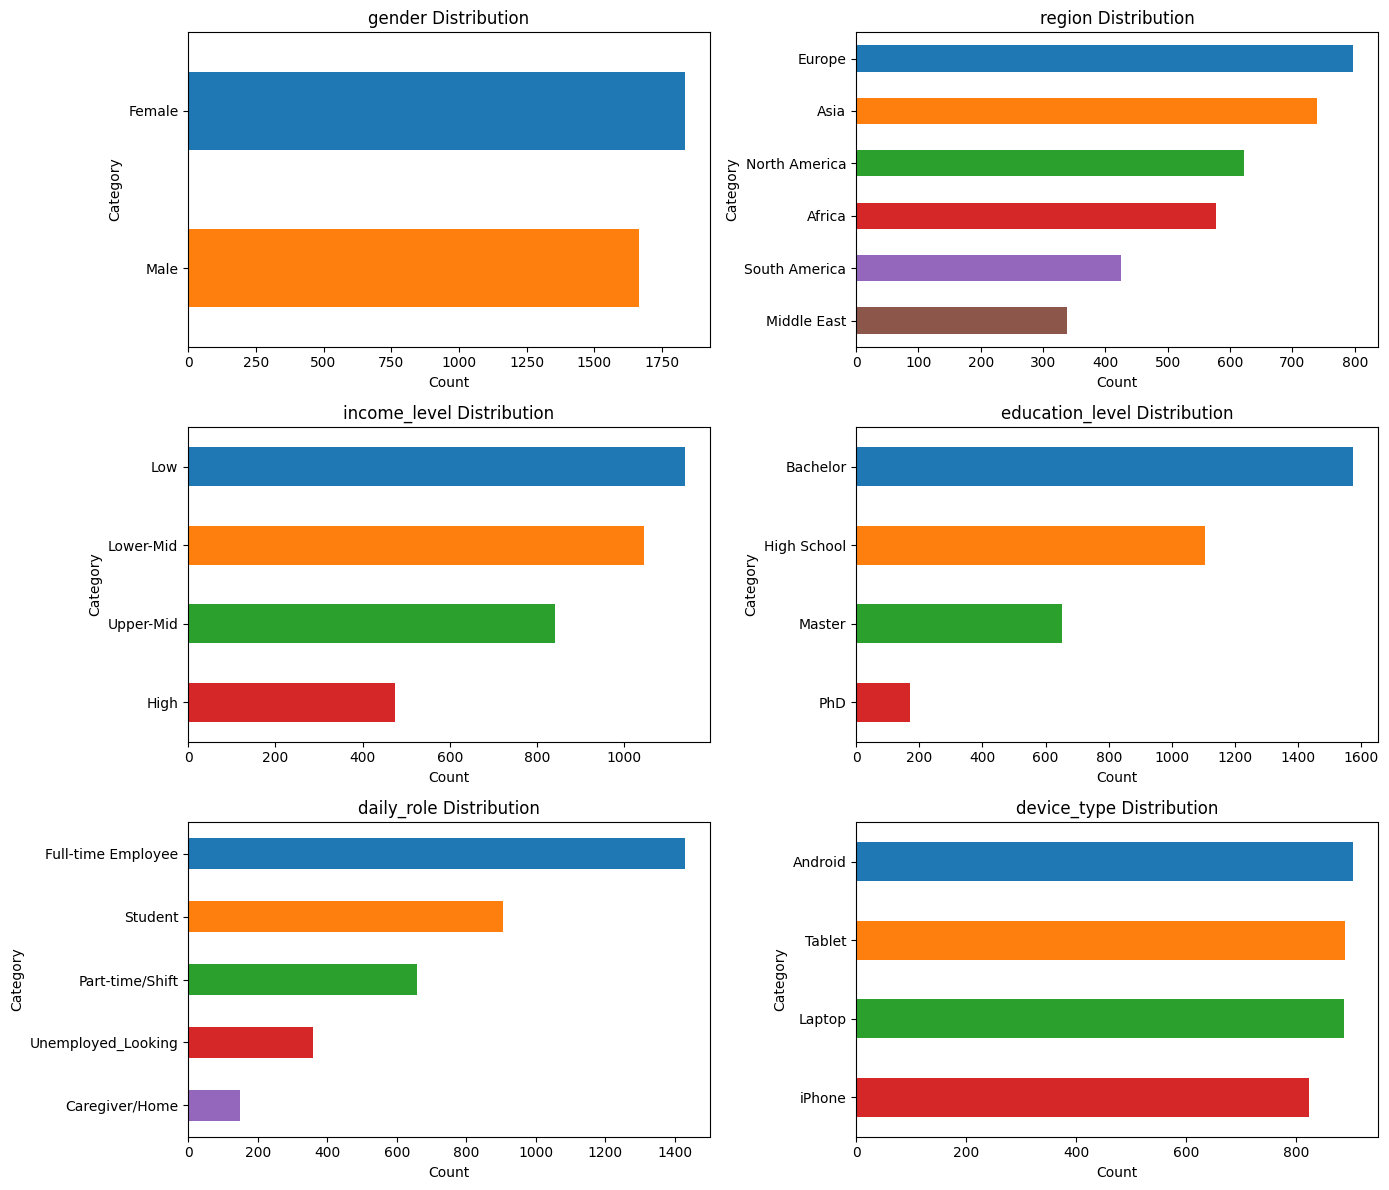

In [23]:


cols = ['gender', 'region', 'income_level', 
        'education_level', 'daily_role', 'device_type']

fig, axes = plt.subplots(3, 2, figsize=(14, 12))

axes = axes.flatten()  
for i in range(len(cols)):
    
    col = cols[i]
    
    categorial_df[col].value_counts().plot(
        kind='barh',
        color=plt.cm.tab10.colors,
        ax=axes[i]
    )
    
    axes[i].set_title(col + " Distribution")
    axes[i].set_xlabel("Count")
    axes[i].set_ylabel("Category")
    axes[i].invert_yaxis()

plt.tight_layout()
plt.show()

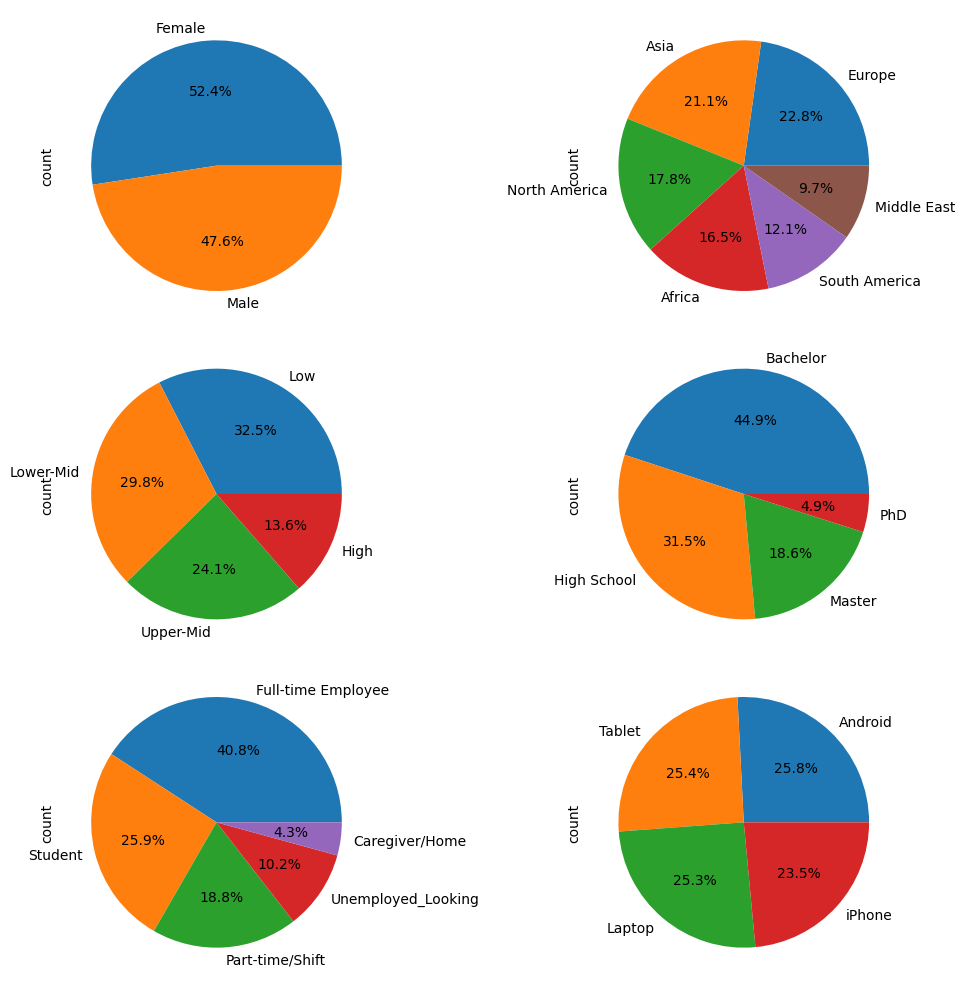

In [24]:

cols = ['gender', 'region', 'income_level', 
        'education_level', 'daily_role', 'device_type']
fig , axes = plt.subplots(3,2,figsize = (12,10))
axes = axes.flatten()
for i in range(len(cols)):
    col = cols[i]
    
    categorial_df[col].value_counts().plot(
        kind="pie",
        autopct ='%1.1f%%',
        color=plt.cm.tab10.colors,
        ax=axes[i]
    )
    plt.tight_layout()

In [25]:
numeric_df.columns

Index(['age', 'device_hours_per_day', 'phone_unlocks', 'notifications_per_day',
       'social_media_mins', 'study_mins', 'physical_activity_days',
       'sleep_hours', 'sleep_quality', 'anxiety_score', 'depression_score',
       'stress_level', 'happiness_score', 'focus_score', 'high_risk_flag',
       'productivity_score', 'digital_dependence_score'],
      dtype='object')

In [26]:
print(len(numeric_df.columns))

17


In [27]:
numeric_df = numeric_df.drop(columns=['high_risk_flag'])

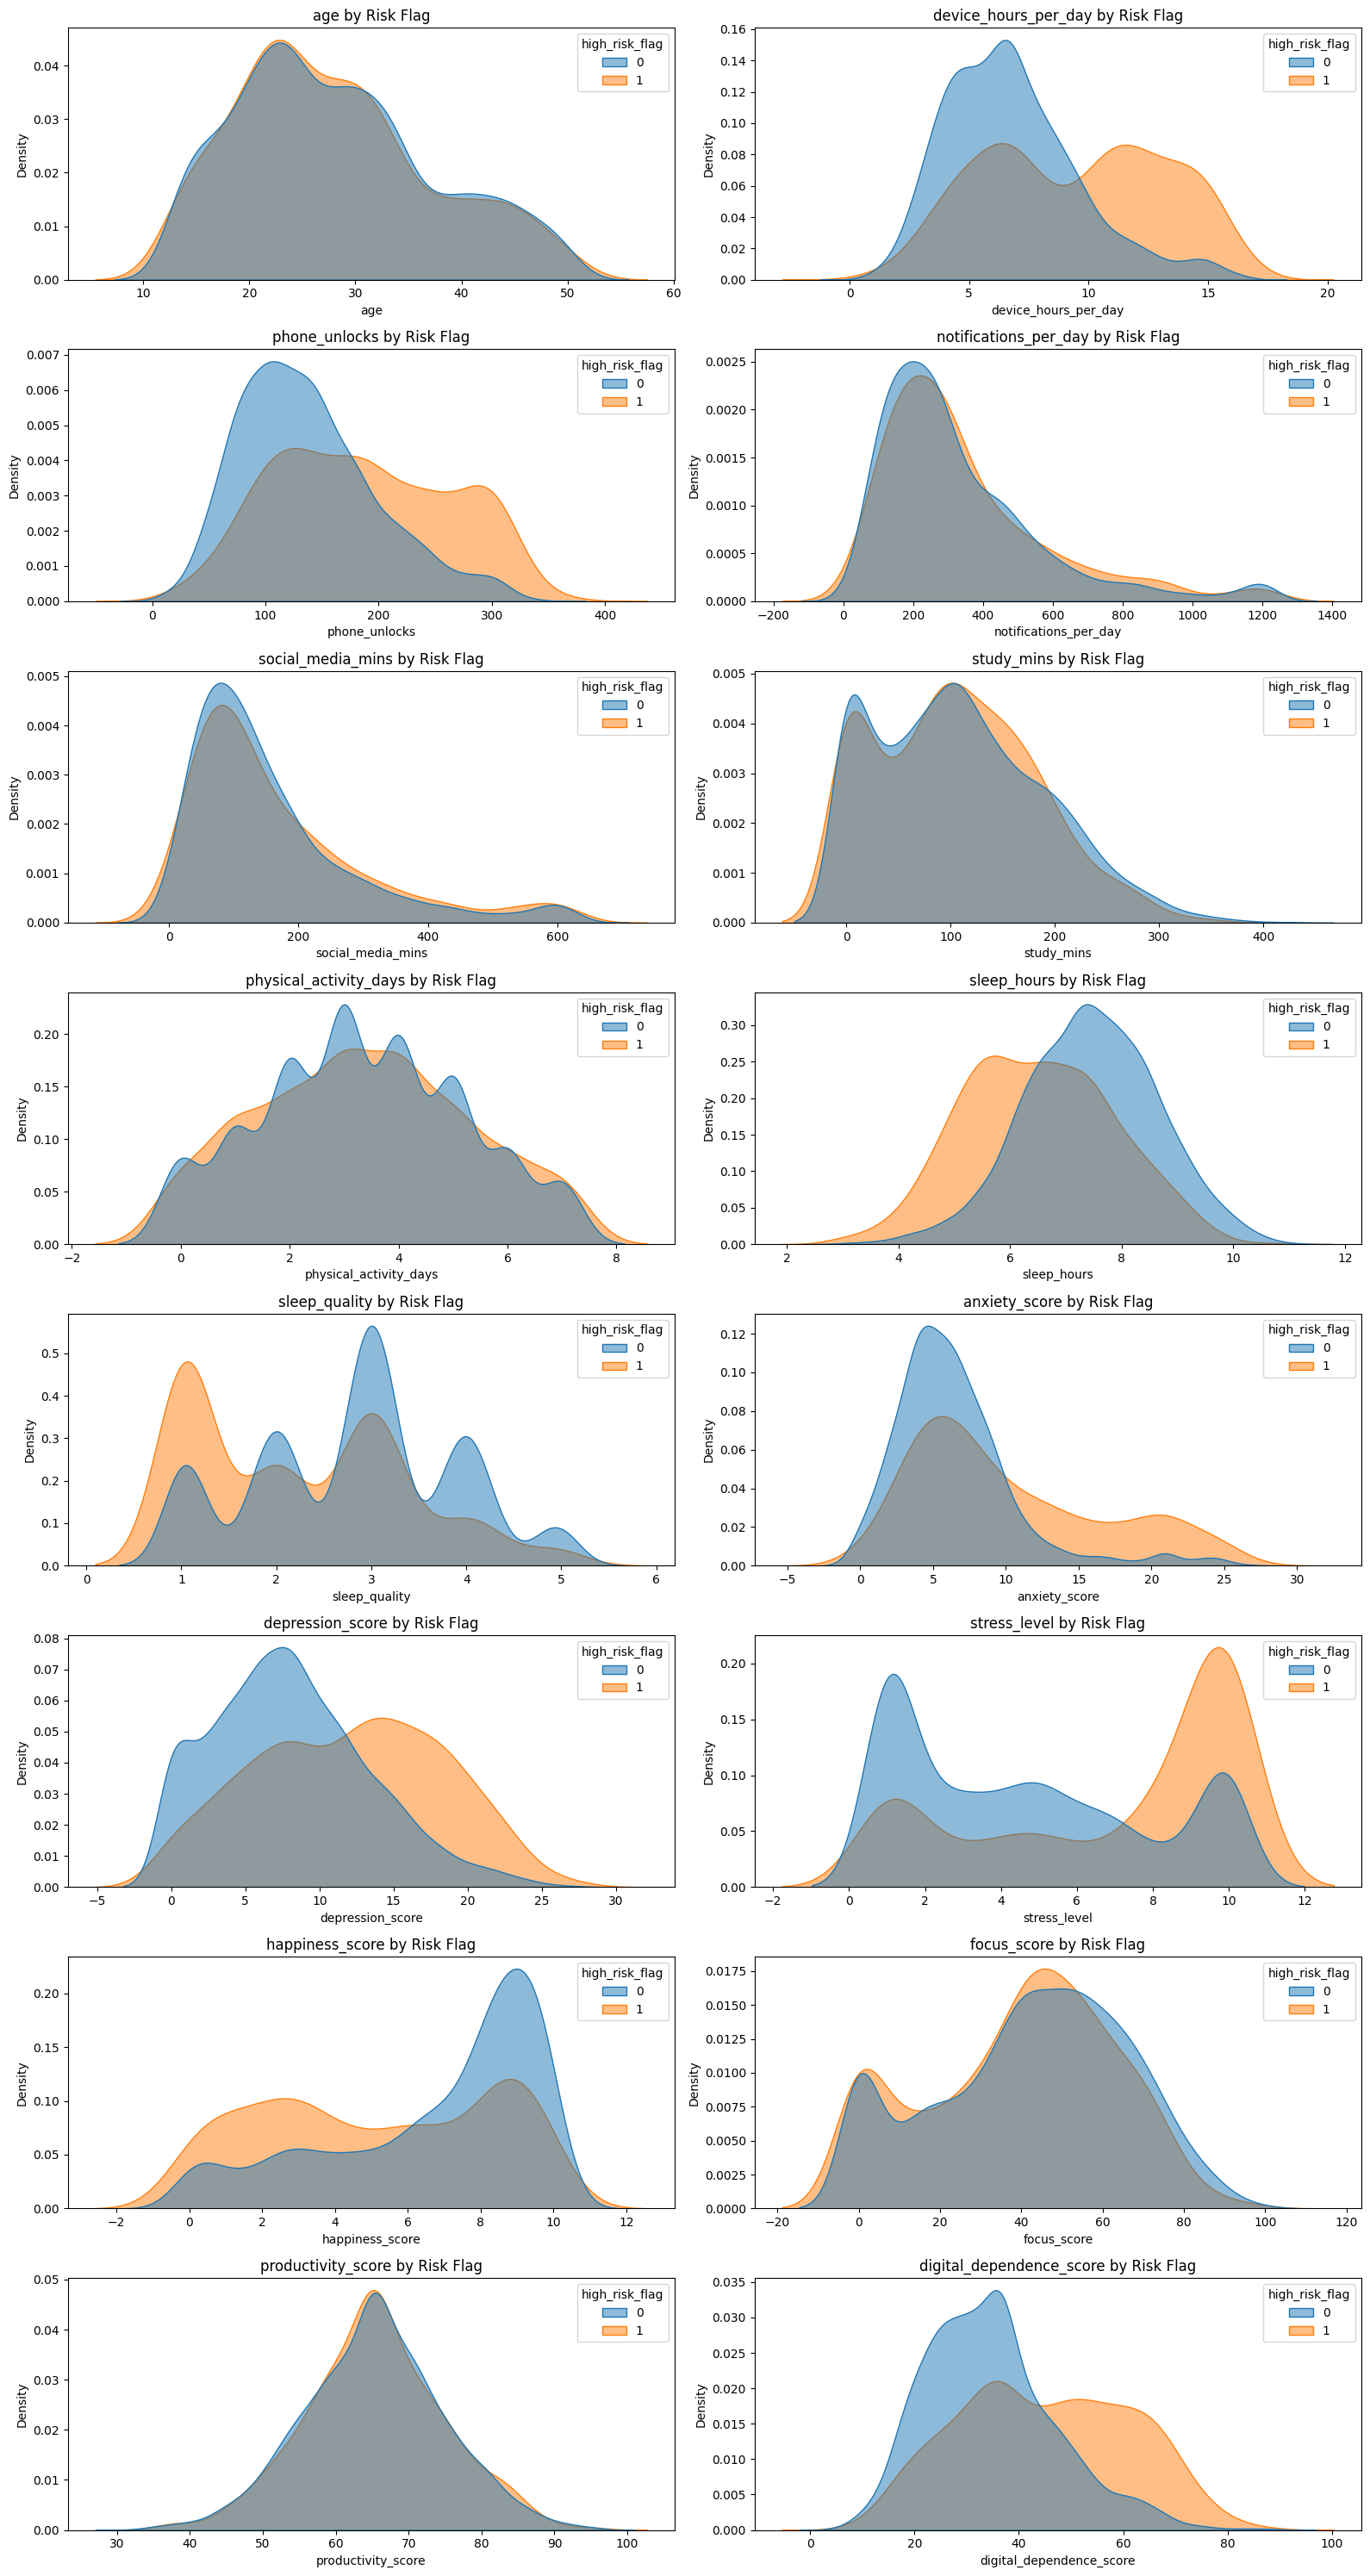

In [28]:
cols = ['age', 'device_hours_per_day', 'phone_unlocks', 'notifications_per_day',
        'social_media_mins', 'study_mins', 'physical_activity_days',
        'sleep_hours', 'sleep_quality', 'anxiety_score', 'depression_score',
        'stress_level', 'happiness_score', 'focus_score',
        'productivity_score', 'digital_dependence_score']


fig, axes = plt.subplots(8, 2, figsize=(16, 30))

axes = axes.flatten()

for i, col in enumerate(cols):
    
    sns.kdeplot(
        data=df,
        x=col,
        hue='high_risk_flag',
        fill=True,
        common_norm=False,
        alpha=0.5,
        ax=axes[i]
    )
    
    axes[i].set_title(f"{col} by Risk Flag")

plt.tight_layout()
plt.show()

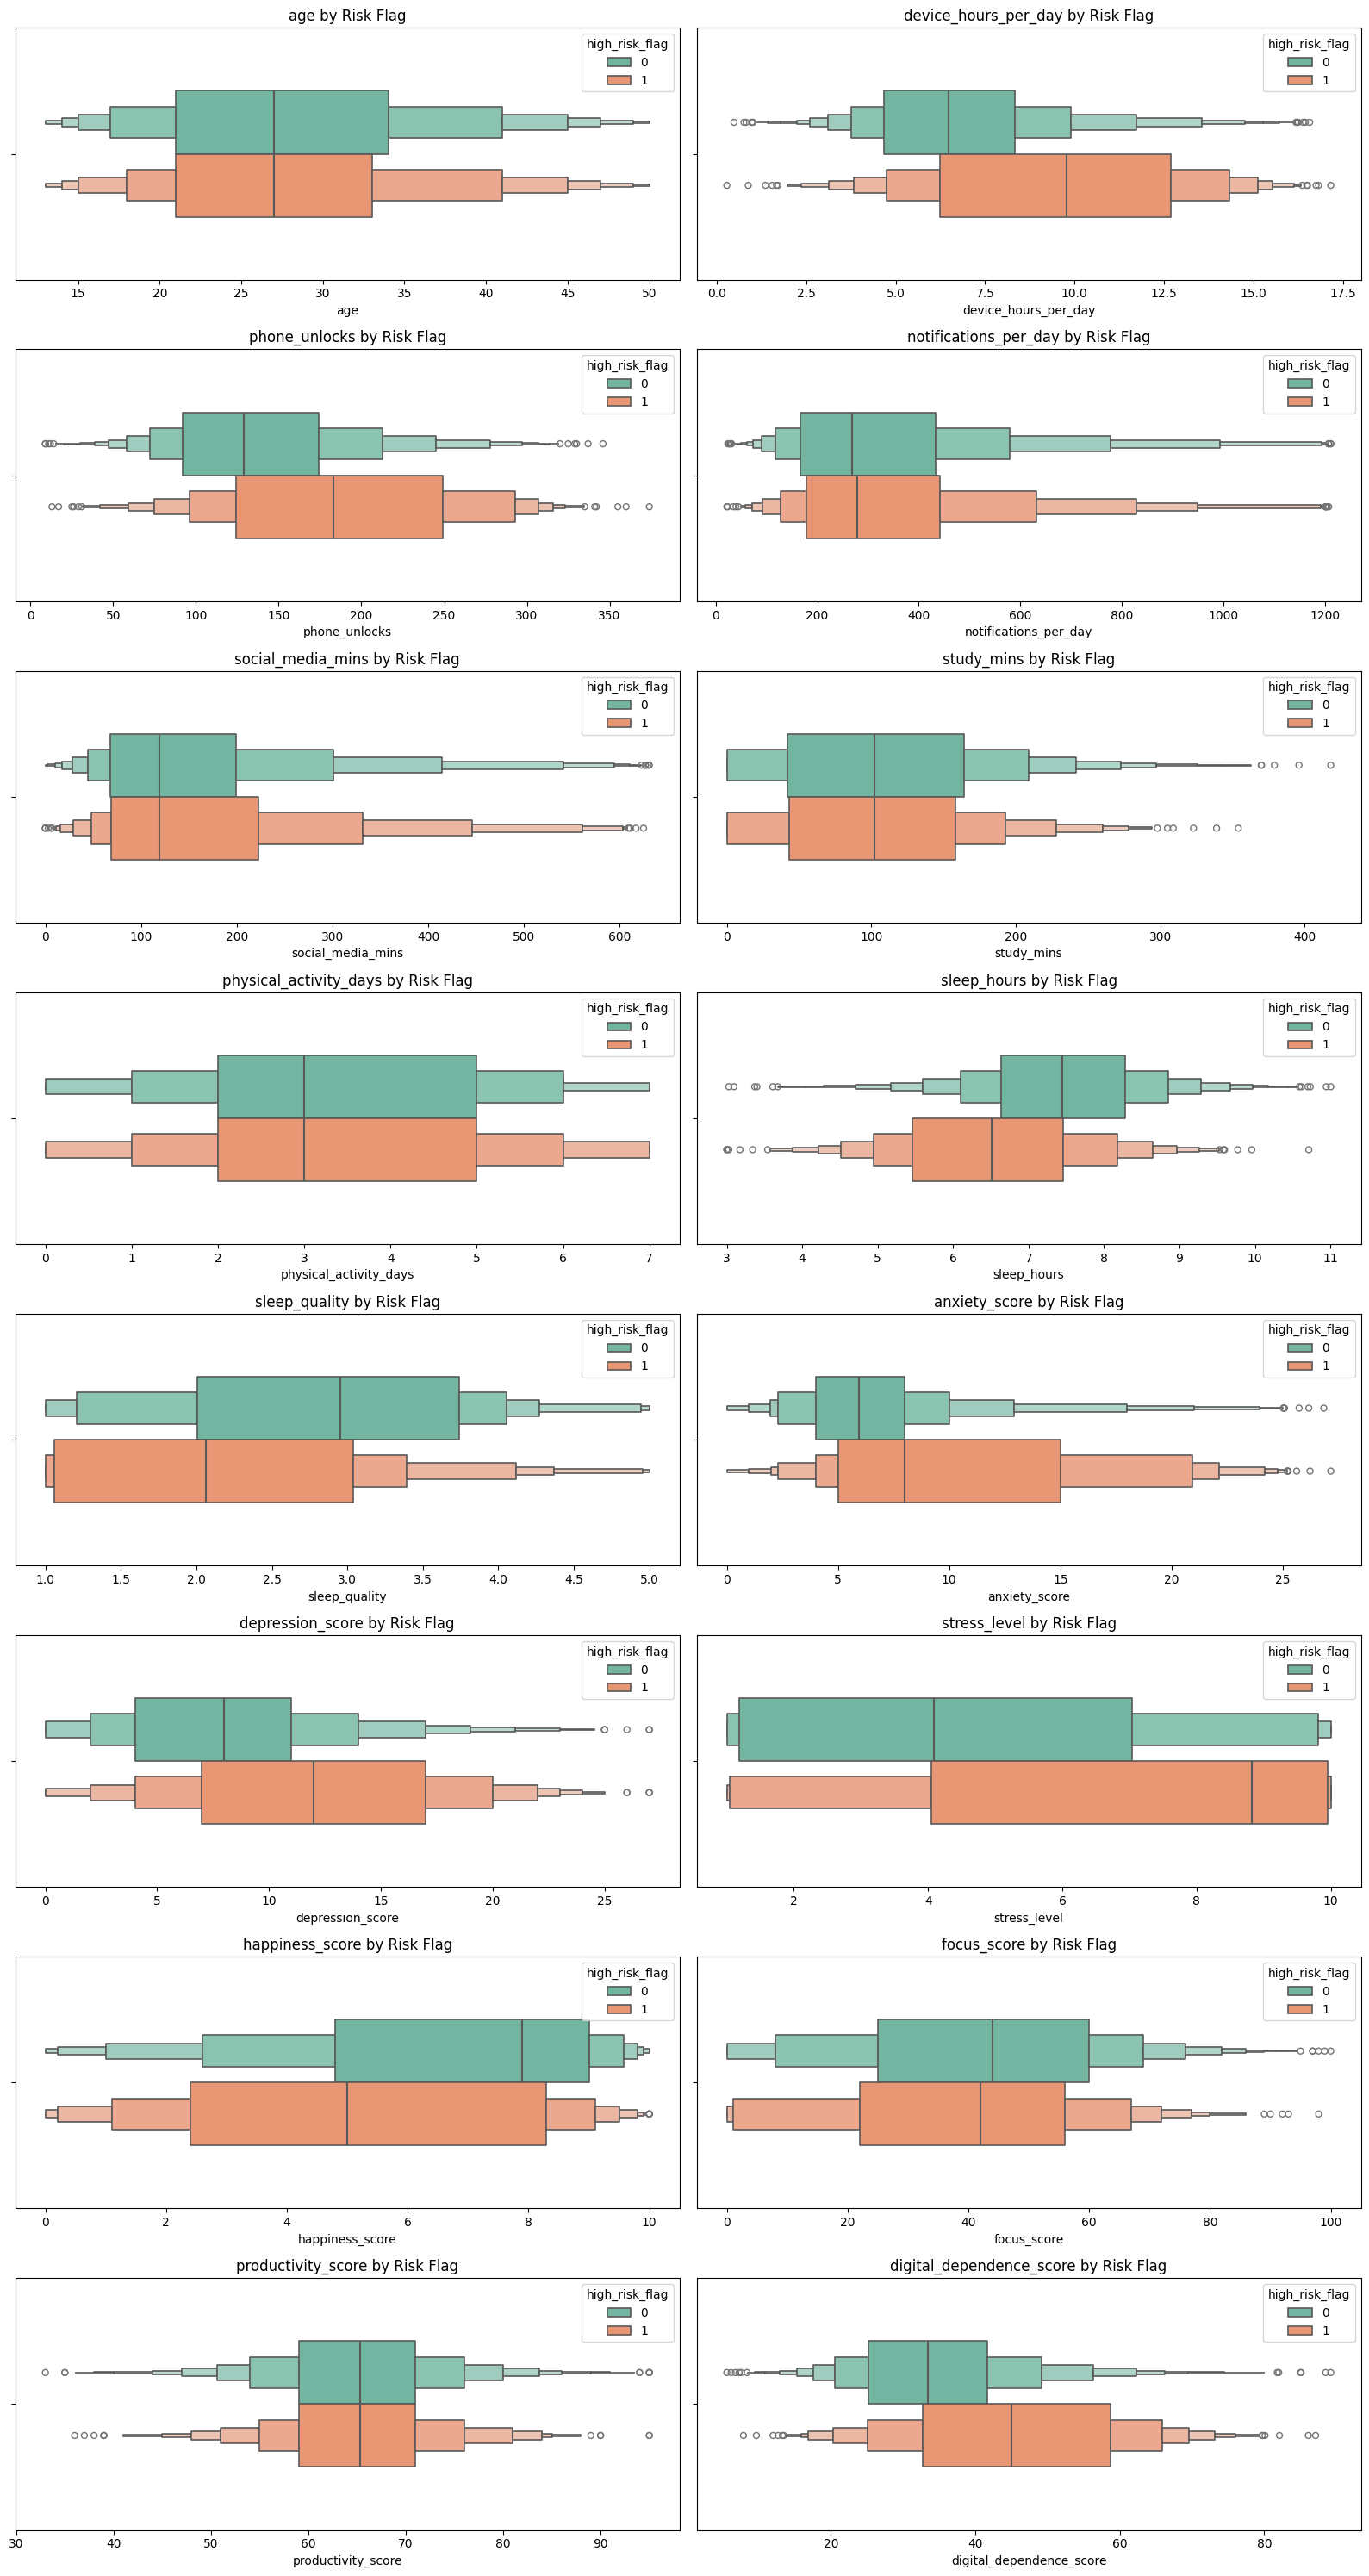

In [29]:
cols = ['age', 'device_hours_per_day', 'phone_unlocks', 'notifications_per_day',
        'social_media_mins', 'study_mins', 'physical_activity_days',
        'sleep_hours', 'sleep_quality', 'anxiety_score', 'depression_score',
        'stress_level', 'happiness_score', 'focus_score',
        'productivity_score', 'digital_dependence_score']

fig, axes = plt.subplots(8, 2, figsize=(16, 30))
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.boxenplot(
        data=df,
        x=col,
        hue='high_risk_flag',
        palette="Set2",
        width=0.5,
        linewidth=1.2,
        
        ax=axes[i]
    )

    axes[i].set_title(f"{col} by Risk Flag")


plt.tight_layout()
plt.show()

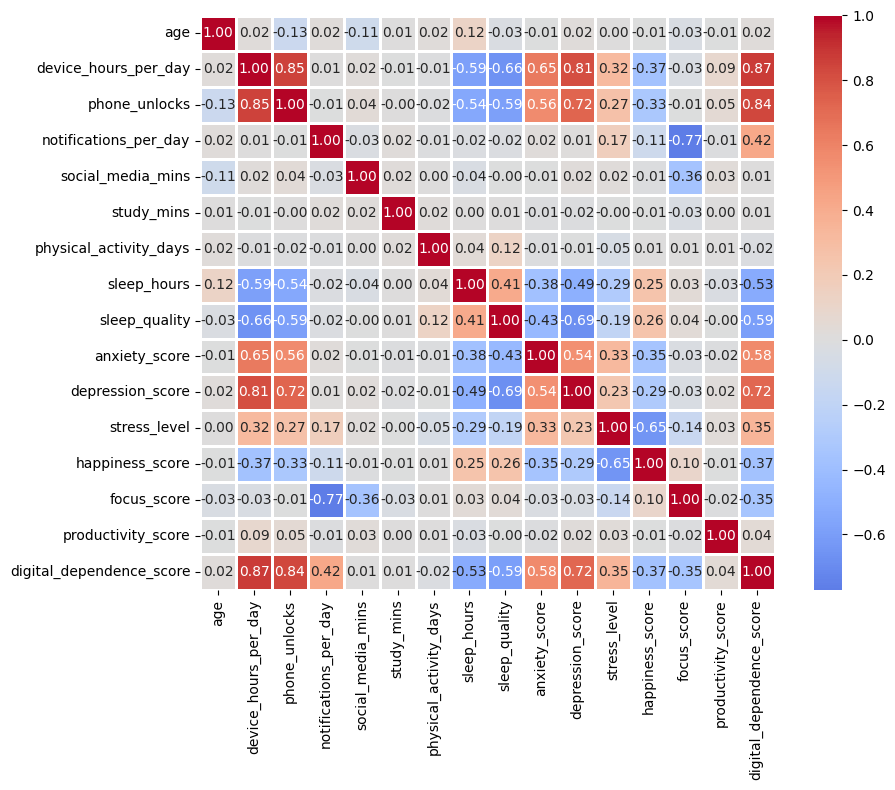

In [30]:
corr = numeric_df.corr()
plt.figure(figsize=(10,8))
sns.heatmap(
    corr,
    annot=True,
    fmt= '.2f',
    cmap="coolwarm",
    center= 0,
    square= True,
    linewidths=1
    
    
)
plt.tight_layout()
plt.show()

In [31]:
categorial_df.columns

Index(['gender', 'region', 'income_level', 'education_level', 'daily_role',
       'device_type'],
      dtype='object')

In [32]:
df["high_risk_flag"].value_counts()

high_risk_flag
0    2795
1     705
Name: count, dtype: int64

## Target Data is imbalanced 

In [33]:
df_copy = df.copy()

In [34]:
df_copy["education_level"].value_counts()

education_level
Bachelor       1573
High School    1103
Master          652
PhD             172
Name: count, dtype: int64

In [35]:
df_copy["income_level"].value_counts()

income_level
Low          1139
Lower-Mid    1044
Upper-Mid     842
High          475
Name: count, dtype: int64

In [36]:
income_level_cat_to_num = {"Low": 0,"Lower-Mid":1,"Upper-Mid":2,"High":3}
education_level_cat_to_num = {"High School":0,"Bachelor":1,"Master":2,"PhD":3}
df_copy["income_level"] = df_copy["income_level"].map(income_level_cat_to_num)
df_copy["education_level"] = df_copy["education_level"].map(education_level_cat_to_num)


In [37]:
df_copy.head(3)

,age,gender,region,income_level,education_level,daily_role,device_hours_per_day,phone_unlocks,notifications_per_day,social_media_mins,...,sleep_quality,anxiety_score,depression_score,stress_level,happiness_score,focus_score,high_risk_flag,device_type,productivity_score,digital_dependence_score
0,40,Female,Asia,3,0,Part-time/Shift,3.54,45,561,98,...,3.353627,9.926651,5.0,6.593289,8.0,23.0,0,Android,70.000000,25.7
1,27,Male,Africa,1,2,Full-time Employee,5.65,100,393,174,...,2.908147,4.000000,4.0,4.126926,8.1,35.0,0,Laptop,64.000000,30.1
2,31,Male,North America,1,1,Full-time Employee,8.87,181,231,595,...,2.889213,4.000000,8.0,1.429139,7.6,15.0,0,Android,65.299301,40.6


In [38]:
x = df_copy.drop(columns="high_risk_flag")
y = df_copy["high_risk_flag"]

In [39]:
onehot_cols = ['gender', 'region', 'income_level', 'education_level', 'daily_role',
       'device_type']
preprocessor = ColumnTransformer(
    transformers=[
        ("cat",OneHotEncoder(handle_unknown="ignore"),onehot_cols)
    ],
    remainder='passthrough')
X_processed = preprocessor.fit_transform(x)

In [40]:
X_processed.shape

(3500, 41)

In [41]:
X_processed = pd.DataFrame(X_processed,columns=preprocessor.get_feature_names_out())

In [42]:
X_processed

,cat__gender_Female,cat__gender_Male,cat__region_Africa,cat__region_Asia,cat__region_Europe,cat__region_Middle East,cat__region_North America,cat__region_South America,cat__income_level_0,cat__income_level_1,...,remainder__physical_activity_days,remainder__sleep_hours,remainder__sleep_quality,remainder__anxiety_score,remainder__depression_score,remainder__stress_level,remainder__happiness_score,remainder__focus_score,remainder__productivity_score,remainder__digital_dependence_score
0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,7.0,9.123800,3.353627,9.926651,5.0,6.593289,8.0,23.0,70.000000,25.700000
1,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,2.0,8.837517,2.908147,4.000000,4.0,4.126926,8.1,35.0,64.000000,30.100000
2,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,...,1.0,6.486743,2.889213,4.000000,8.0,1.429139,7.6,15.0,65.299301,40.600000
3,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,4.0,7.600504,3.097488,7.093357,9.0,4.995512,7.8,28.0,80.000000,36.684152
4,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,1.0,5.197962,2.786098,7.028125,15.0,9.448757,4.2,70.0,65.299301,48.400000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3495,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,3.0,6.128898,2.950001,4.772862,9.0,7.076726,2.4,59.0,84.000000,29.600000
3496,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,4.0,6.699823,3.124953,5.520824,2.0,1.000000,8.9,27.0,73.000000,23.200000
3497,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,6.0,6.590077,2.269790,8.518051,11.0,1.783568,7.6,56.0,65.000000,42.400000
3498,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,...,2.0,9.626066,4.902579,4.238655,8.0,10.000000,2.8,52.0,63.000000,20.500000


In [43]:
x_train, x_test , y_train ,y_test = train_test_split(X_processed,y, test_size=0.2,random_state=42)

In [44]:
scaler = StandardScaler()
x_train_scale = scaler.fit_transform(x_train)
x_test_scale = scaler.transform(x_test)

In [45]:
x_train_scale

array([[ 0.96214456, -0.96214456, -0.44222093, ...,  2.37447475,
         1.18683702, -0.48547909],
       [-1.03934486,  1.03934486, -0.44222093, ...,  0.28479469,
         0.88036643, -1.18746419],
       [ 0.96214456, -0.96214456, -0.44222093, ..., -1.01080695,
         0.6760527 , -0.10257813],
       ...,
       [ 0.96214456, -0.96214456, -0.44222093, ...,  0.6191435 ,
         0.06311151, -0.33657316],
       [ 0.96214456, -0.96214456, -0.44222093, ...,  1.12066671,
         0.16526837,  0.3725027 ],
       [ 0.96214456, -0.96214456, -0.44222093, ..., -0.92721974,
        -1.06061401, -0.91801536]], shape=(2800, 41))

In [46]:
random_forest = RandomForestClassifier()
random_forest.fit(x_train_scale,y_train)
y_pred = random_forest.predict(x_test_scale)

In [47]:
print("accuracy score :",accuracy_score(y_test,y_pred))

accuracy score : 0.8785714285714286


In [48]:
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

rf = RandomForestClassifier(random_state=42, n_jobs=-1,
                            class_weight={0: 1, 1: 4})  # weights to handle imbalance

param_grid = {
    'n_estimators': [50, 75, 100],
    'max_depth': [5, 10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)


grid_search.fit(x_train_scale, y_train)



Fitting 3 folds for each of 108 candidates, totalling 324 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [5, 10, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [50, 75, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computat

In [49]:
best_rf  = grid_search.best_estimator_
print("\n Best Parameters:")
print(grid_search.best_params_)
print("\n Best CV ROC-AUC:", grid_search.best_score_)


 Best Parameters:
{'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 75}

 Best CV ROC-AUC: 0.7861586608420214



 Test Accuracy: 0.8785714285714286

 ROC-AUC Score: 0.7269947601466651

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.97      0.93       559
           1       0.81      0.52      0.63       141

    accuracy                           0.88       700
   macro avg       0.85      0.74      0.78       700
weighted avg       0.87      0.88      0.87       700



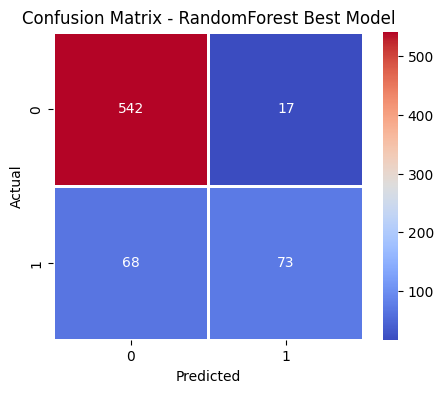

In [50]:
y_pred = best_rf .predict(x_test_scale)
y_pred_proba = best_rf .predict_proba(x_test_scale)[:, 1]  

print("\n Test Accuracy:", accuracy_score(y_test, y_pred))
print("\n ROC-AUC Score:", roc_auc_score(y_test, y_pred_proba))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='coolwarm', linewidths=2)
plt.title("Confusion Matrix - RandomForest Best Model")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [51]:
categorical_cols = [
    'gender','region','income_level',
    'education_level','daily_role','device_type'
]

numerical_cols = [
    'age','device_hours_per_day','phone_unlocks',
    'notifications_per_day','social_media_mins',
    'study_mins','physical_activity_days','sleep_hours',
    'sleep_quality','productivity_score','digital_dependence_score'
]

In [52]:
preprocessor_new = ColumnTransformer(
    transformers= [
        ('onehot',OneHotEncoder(handle_unknown='ignore'),categorical_cols),
        ('scaler',StandardScaler(),numerical_cols)
    ]
)

In [53]:
pipeline = Pipeline([
    ("preprocessor",preprocessor_new),
    ("model",XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    random_state=42
))
])
# pipeline = Pipeline([
#     ("preprocessor",preprocessor_new),
#     ("model",RandomForestClassifier(class_weight="balanced"))
# ])

In [54]:
x_new = df.drop(columns="high_risk_flag")
y_new = df["high_risk_flag"]

In [55]:
x_train_new,x_test_new , y_train_new,y_test_new = train_test_split(x_new,y_new,test_size=0.5,random_state=42)

In [56]:
pipeline.fit(x_train_new,y_train_new)
y_pred_new = pipeline.predict(x_test_new)

In [57]:
print("accuracy score :",accuracy_score(y_test_new,y_pred_new))

accuracy score : 0.808


In [ ]:

import os
import pickle

os.makedirs("models", exist_ok=True)

with open("models/mental_health_model.pkl", "wb") as f:
    pickle.dump(pipeline, f)